In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
from collections import defaultdict
from collections import Counter

In [148]:
df = pd.read_csv("/content/events.csv")

# PHASE 1 — Data Understanding

In [149]:
df

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


In [150]:
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [151]:
df.tail()

,timestamp,visitorid,event,itemid,transactionid
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN
2756100,1438400163914,199536,view,152913,NaN


In [152]:
nRow, nCol = df.shape
print(f"dataset contain {nRow} rows, and {nCol} columns")

dataset contain 2756101 rows, and 5 columns


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [154]:
df.isnull().sum()

,0
timestamp,0
visitorid,0
event,0
itemid,0
transactionid,2733644


In [155]:
print("\n=== UNIQUE COUNTS ===")
print("visitorid:", df["visitorid"].nunique())
print("itemid:", df["itemid"].nunique())
print("event:", df["event"].nunique())
print("transactionid:", df["transactionid"].nunique())


=== UNIQUE COUNTS ===
visitorid: 1407580
itemid: 235061
event: 3
transactionid: 17672


In [156]:
print("\n=== EVENT VALUE COUNTS ===")
print(df["event"].value_counts())
print("\n=== EVENT PERCENTAGES ===")
print(df["event"].value_counts(normalize=True) * 100)


=== EVENT VALUE COUNTS ===
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

=== EVENT PERCENTAGES ===
event
view           96.669607
addtocart       2.515583
transaction     0.814810
Name: proportion, dtype: float64


In [157]:
print("\n=== TIMESTAMP RANGE ===")
print("Min timestamp:", df["timestamp"].min())
print("Max timestamp:", df["timestamp"].max())


=== TIMESTAMP RANGE ===
Min timestamp: 1430622004384
Max timestamp: 1442545187788


In [158]:
# Is transactionid populated only in transaction events?
print("=== Relationship between 'transactionid' and 'event' ===")
print(df.groupby("event")["transactionid"].apply(lambda x: x.notna().sum())) # non null values - opposite of isna

=== Relationship between 'transactionid' and 'event' ===
event
addtocart          0
transaction    22457
view               0
Name: transactionid, dtype: int64


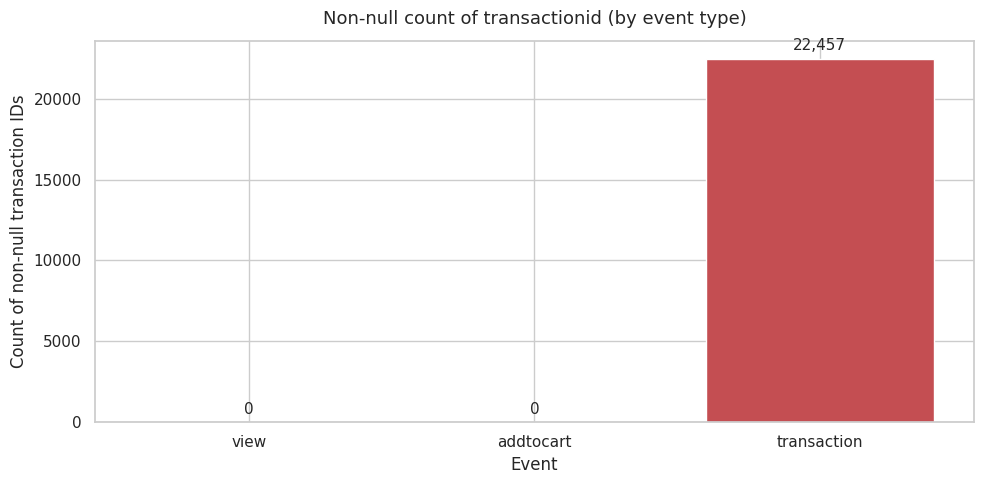

In [159]:
# transactionid vs event (non-null counts)

non_null = df.groupby("event")["transactionid"].apply(lambda x: x.notna().sum())
non_null = non_null.reindex(["view", "addtocart", "transaction"])  # məntiqi sıra

fig, ax = plt.subplots()
bars = ax.bar(non_null.index, non_null.values, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Non-null count of transactionid (by event type)", fontsize=13, pad=12)
ax.set_ylabel("Count of non-null transaction IDs")
ax.set_xlabel("Event")

# Write the values ​​on the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height):,}",
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

In [160]:
# How many items can a single transactionid contain?
print("\n=== Number of items in a transaction ===")
trans = df[df["event"] == "transaction"]
print(trans.groupby("transactionid")["itemid"].nunique().describe())


=== Number of items in a transaction ===
count    17672.000000
mean         1.263185
std          0.940747
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         31.000000
Name: itemid, dtype: float64


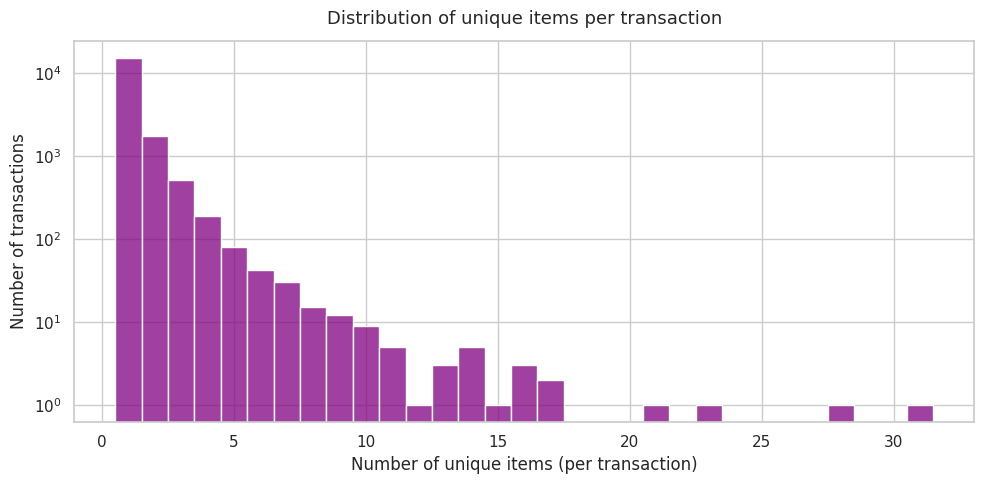

In [161]:
# Number of unique items per transaction

trans = df[df["event"] == "transaction"]
items_per_trans = trans.groupby("transactionid")["itemid"].nunique()

fig, ax = plt.subplots()
sns.histplot(items_per_trans, bins=range(1, items_per_trans.max() + 2),
             discrete=True, ax=ax, color = 'purple')
ax.set_title("Distribution of unique items per transaction", fontsize=13, pad=12)
ax.set_xlabel("Number of unique items (per transaction)")
ax.set_ylabel("Number of transactions")
ax.set_yscale("log")  # log scale because most transactions have only 1 item
plt.tight_layout()
plt.show()

In [162]:
# Is there an exact duplicate row?
print("\n=== Number of exact duplicate rows ===")
print(df.duplicated().sum())


=== Number of exact duplicate rows ===
460


In [163]:
# Is there the same visitor + item + event + timestamp combination?
print("\n=== visitorid + itemid + event + timestamp duplicates ===")
print(df.duplicated(subset=["visitorid", "itemid", "event", "timestamp"]).sum())


=== visitorid + itemid + event + timestamp duplicates ===
460


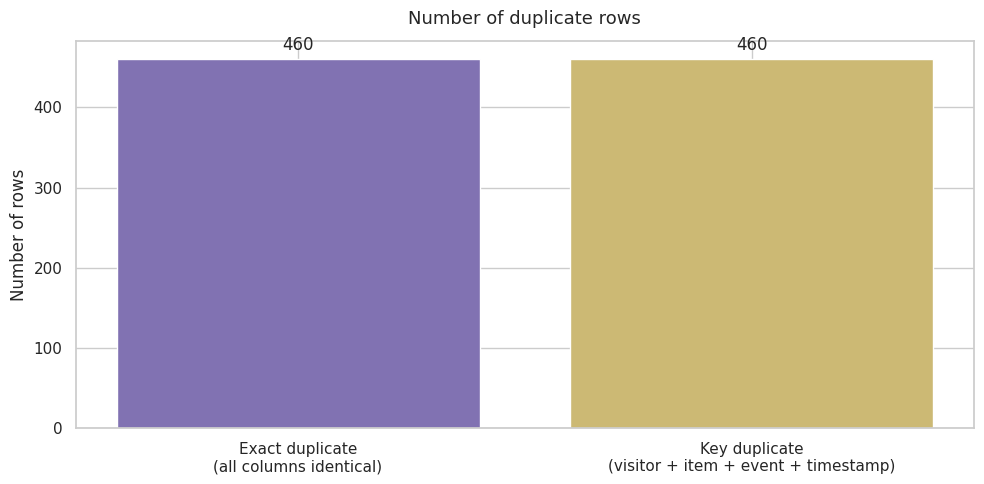

In [164]:
# Duplicate counts (exact + key combination)
exact_dup = df.duplicated().sum()
key_dup   = df.duplicated(subset=["visitorid", "itemid", "event", "timestamp"]).sum()

fig, ax = plt.subplots()
labels = ["Exact duplicate\n(all columns identical)",
          "Key duplicate\n(visitor + item + event + timestamp)"]
values = [exact_dup, key_dup]
bars = ax.bar(labels, values, color=["#8172B2", "#CCB974"])
ax.set_title("Number of duplicate rows", fontsize=13, pad=12)
ax.set_ylabel("Number of rows")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height):,}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

# PHASE 2 — Data Quality Analysis

In [165]:
# Sample of duplicates
print("=== Duplicate line example ===")
print(df[df.duplicated(keep=False)].sort_values(["visitorid", "timestamp"]).head(10))

=== Duplicate line example ===
             timestamp  visitorid      event  itemid  transactionid
1041548  1440547735041        745  addtocart  246164            NaN
1051024  1440547735041        745  addtocart  246164            NaN
301904   1434501277715       3926  addtocart  323347            NaN
319376   1434501277715       3926  addtocart  323347            NaN
113491   1433611737367      10162  addtocart  146661            NaN
124035   1433611737367      10162  addtocart  146661            NaN
1965082  1432707397977      12046  addtocart  205663            NaN
1983425  1432707397977      12046  addtocart  205663            NaN
1166547  1441151647762      12560  addtocart  272976            NaN
1167841  1441151647762      12560  addtocart  272976            NaN


In [166]:
# Timestamp statistics
print("\n=== Timestamp statistics ===")
print(df["timestamp"].describe())


=== Timestamp statistics ===
count    2.756101e+06
mean     1.436424e+12
std      3.366312e+09
min      1.430622e+12
25%      1.433478e+12
50%      1.436453e+12
75%      1.439225e+12
max      1.442545e+12
Name: timestamp, dtype: float64


In [167]:
# Negative or zero ID check
print("\n=== Negative / zero ID check ===")
print("visitorid <= 0:", (df["visitorid"] <= 0).sum())
print("itemid <= 0:", (df["itemid"] <= 0).sum())
print("transactionid <= 0 (non-null):", ((df["transactionid"] <= 0) & df["transactionid"].notna()).sum())


=== Negative / zero ID check ===
visitorid <= 0: 3
itemid <= 0: 0
transactionid <= 0 (non-null): 1


In [168]:
# How many times do the same user, same product, same event, and same timestamp repeat?
print("\n=== Same number of simultaneous interactions- ===")
dup_counts = df.groupby(["visitorid", "itemid", "event", "timestamp"]).size()
print(dup_counts[dup_counts > 1].value_counts().sort_index())


=== Same number of simultaneous interactions- ===
2    456
3      2
Name: count, dtype: int64


# PHASE 3 — Data Cleaning

In [169]:
print("=== Shape before cleaning ===")
print(df.shape)

# Delete exact duplicates
df = df.drop_duplicates()

=== Shape before cleaning ===
(2756101, 5)


In [170]:
# Delete anomalous visitor IDs
df = df[df["visitorid"] > 0]

# Delete anomalous transaction IDs (only among non-null ones)
df = df[~((df["transactionid"].notna()) & (df["transactionid"] <= 0))]

print("\n=== Shape after cleaning ===")
print(df.shape)


=== Shape after cleaning ===
(2755637, 5)


In [171]:
# Convert the timestamp to datetime (in milliseconds).
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

print("\n=== Datetime range ===")
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Duration (days):", (df["datetime"].max() - df["datetime"].min()).days)


=== Datetime range ===
Start: 2015-05-03 03:00:04.384000
End: 2015-09-18 02:59:47.788000
Duration (days): 137


In [172]:
# Final check
print("\n=== Missing values ​​after cleaning ===")
print(df.isna().sum())

print("\n=== Event distribution after cleaning ===")
print(df["event"].value_counts())


=== Missing values ​​after cleaning ===
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733181
datetime               0
dtype: int64

=== Event distribution after cleaning ===
event
view           2664215
addtocart        68966
transaction      22456
Name: count, dtype: int64


# PHASE 4 — Exploratory Data Analysis (EDA)

In [173]:
print("=== User activity distribution ===")
user_activity = df.groupby("visitorid").size()
print(user_activity.describe())

=== User activity distribution ===
count    1.407579e+06
mean     1.957714e+00
std      1.257982e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64


In [174]:
print("\n=== What percentage of users had only one interaction? ===")
print((user_activity == 1).mean() * 100)


=== What percentage of users had only one interaction? ===
71.15700077935236


In [175]:
print("\n=== Product popularity distribution ===")
item_popularity = df.groupby("itemid").size()
print(item_popularity.describe())


=== Product popularity distribution ===
count    235061.000000
mean         11.723072
std          37.024727
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64


In [176]:
print("\n=== What percentage of products received only one interaction? ===")
print((item_popularity == 1).mean() * 100)


=== What percentage of products received only one interaction? ===
31.31782813822795


In [177]:
print("\n=== Funnel analysis (view → addtocart → transaction) ===")
print("\nConversion rates:")
event_counts = df["event"].value_counts()

views = event_counts.get("view", 0) # If there is a "view", give me its count. If not, return 0
carts = event_counts.get("addtocart", 0)
transactions = event_counts.get("transaction", 0)

print("View → Addtocart:",
      round((carts / views) * 100, 3), "%")

print("Addtocart → Transaction:",
      round((transactions / carts) * 100, 3), "%")

print("View → Transaction:",
      round((transactions / views) * 100, 3), "%")


=== Funnel analysis (view → addtocart → transaction) ===

Conversion rates:
View → Addtocart: 2.589 %
Addtocart → Transaction: 32.561 %
View → Transaction: 0.843 %


In [178]:
print("=== Sparsity calculation ===")
n_users = df["visitorid"].nunique()
n_items = df["itemid"].nunique()
n_interactions = len(df)

sparsity = 1 - (n_interactions / (n_users * n_items))
print(f"Users: {n_users:,}")
print(f"Items: {n_items:,}")
print(f"Interactions: {n_interactions:,}")
print(f"Sparsity: {sparsity:.6%}")

=== Sparsity calculation ===
Users: 1,407,579
Items: 235,061
Interactions: 2,755,637
Sparsity: 99.999167%


In [179]:
print("\n=== Concentration of popularity (Pareto) ===")
# What percentage of all interactions do the top 1%, 5%, and 10% of products account for?
item_counts = df["itemid"].value_counts() # How many interactions were there with which products? (events)
total = item_counts.sum() # What is the total amount of product?

for p in [0.01, 0.05, 0.10, 0.20]:
    top_n = int(len(item_counts) * p)
    share = (item_counts.head(top_n).sum() / total) * 100
    print(f"Top {p*100:.0f}% items → {share:.2f}% of all interactions")


=== Concentration of popularity (Pareto) ===
Top 1% items → 22.95% of all interactions
Top 5% items → 49.32% of all interactions
Top 10% items → 64.03% of all interactions
Top 20% items → 78.71% of all interactions


In [180]:
print("\n=== Most active users ===")
user_counts = df["visitorid"].value_counts()
print(user_counts.head(10))


=== Most active users ===
visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991
Name: count, dtype: int64


In [181]:
print("\n=== Most popular products ===")
print(item_counts.head(10))


=== Most popular products ===
itemid
187946    3412
461686    2975
5411      2334
370653    1854
219512    1800
257040    1647
298009    1642
96924     1633
309778    1628
384302    1608
Name: count, dtype: int64


# PHASE 5 — Understanding User Behavior

In [182]:
print("=== Number of unique products per user ===")
user_items = df.groupby("visitorid")["itemid"].nunique()
print(user_items.describe())
print(f"\nUsers who viewed only 1 product: {(user_items == 1).mean()*100:.2f}%")

=== Number of unique products per user ===
count    1.407579e+06
mean     1.524018e+00
std      7.143726e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.814000e+03
Name: itemid, dtype: float64

Users who viewed only 1 product: 79.53%


In [183]:
print("\n=== Repeated interaction with the same product ===")
# How many times has the same user interacted with the same product?
user_item_counts = df.groupby(["visitorid", "itemid"]).size()
print(user_item_counts.describe())
print(f"\nMore than one interaction for the same user-item pair: {(user_item_counts > 1).mean()*100:.2f}%")


=== Repeated interaction with the same product ===
count    2.145176e+06
mean     1.284574e+00
std      1.231457e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.080000e+02
dtype: float64

More than one interaction for the same user-item pair: 15.52%


In [184]:
print("\n=== Purchasing vs. non-purchasing users ===")
purchasers = df[df["event"] == "transaction"]["visitorid"].unique()
print(f"Number of purchasing users: {len(purchasers):,}")
print(f"Percentage of purchasing users: {len(purchasers) / df['visitorid'].nunique() * 100:.3f}%")

# Average number of interactions by purchasers
purchaser_activity = df[df["visitorid"].isin(purchasers)].groupby("visitorid").size()
non_purchaser_activity = df[~df["visitorid"].isin(purchasers)].groupby("visitorid").size() # contradiction

print(f"\nAverage interaction of purchasers: {purchaser_activity.mean():.2f}")
print(f"Average interaction of non-purchasers: {non_purchaser_activity.mean():.2f}")


=== Purchasing vs. non-purchasing users ===
Number of purchasing users: 11,718
Percentage of purchasing users: 0.832%

Average interaction of purchasers: 19.68
Average interaction of non-purchasers: 1.81


In [185]:
print("=== Number of unique products purchased by buyers ===")
purchaser_unique_items = df[df["visitorid"].isin(purchasers)].groupby("visitorid")["itemid"].nunique()
non_purchaser_unique_items = df[~df["visitorid"].isin(purchasers)].groupby("visitorid")["itemid"].nunique()

print(f"Average number of unique products per buyer: {purchaser_unique_items.mean():.2f}")
print(f"Average number of unique products for non-purchasers: {non_purchaser_unique_items.mean():.2f}")
print(f"Median number of unique products per buyer: {purchaser_unique_items.median():.1f}")
print(f"Median number of unique products for non-purchasers: {non_purchaser_unique_items.median():.1f}")

=== Number of unique products purchased by buyers ===
Average number of unique products per buyer: 9.54
Average number of unique products for non-purchasers: 1.46
Median number of unique products per buyer: 2.0
Median number of unique products for non-purchasers: 1.0


In [186]:
print("\n=== Event sequence for the same item (simple check) ===")
# Which events occurred for each user-item pair?
user_item_events = df.groupby(["visitorid", "itemid"])["event"].apply(set)

# In how many pairs are both 'view' and 'add to cart' present?
has_view_and_cart = user_item_events.apply(lambda x: "view" in x and "addtocart" in x).sum()
has_cart_and_transaction = user_item_events.apply(lambda x: "addtocart" in x and "transaction" in x).sum()
has_view_and_transaction = user_item_events.apply(lambda x: "view" in x and "transaction" in x).sum()
has_all_three = user_item_events.apply(lambda x: {"view", "addtocart", "transaction"}.issubset(x)).sum()

print(f"User-item pairs with 'View' and 'Add to Cart' actions: {has_view_and_cart:,}")
print(f"User-item pairs with 'Add to Cart' and 'Transaction' events: {has_cart_and_transaction:,}")
print(f"User-item pairs with 'View' + 'Transaction': {has_view_and_transaction:,}")
print(f"User-item pairs involving all three events: {has_all_three:,}")
print(f"Total unique user-item pairs: {len(user_item_events):,}")


=== Event sequence for the same item (simple check) ===
User-item pairs with 'View' and 'Add to Cart' actions: 49,500
User-item pairs with 'Add to Cart' and 'Transaction' events: 19,044
User-item pairs with 'View' + 'Transaction': 19,050
User-item pairs involving all three events: 17,352
Total unique user-item pairs: 2,145,176


# PHASE 6 — Feature Engineering + PHASE 7 — Defining Implicit Feedback

In [187]:
# Let's assign temporary ordinal weights to the events (not final yet).
event_strength = {
    "view": 1,
    "addtocart": 2,
    "transaction": 3
}

df["event_strength"] = df["event"].map(event_strength)

In [188]:
# Aggregate at the user-item level
user_item = (
    df.groupby(["visitorid", "itemid"])
    .agg(
        interaction_count=("event", "size"),
        max_strength=("event_strength", "max"),
        has_transaction=("event", lambda x: int("transaction" in set(x))),
        has_addtocart=("event", lambda x: int("addtocart" in set(x)))
    )
    .reset_index()
)

In [189]:
# Simple weight: max_strength * log(1 + count) (takes repetitions into account in a smoothed manner)
user_item["weight"] = user_item["max_strength"] * np.log1p(user_item["interaction_count"])

print("=== User-Item Interaction DataFrame ===")
print(f"Shape: {user_item.shape}")
print(f"\nColumns: {list(user_item.columns)}")
print("\n=== weight distribution ===")
print(user_item["weight"].describe())
print("\n=== max_strength distribution ===")
print(user_item["max_strength"].value_counts(normalize=True).sort_index())
print("\n=== interaction_count distribution (top) ===")
print(user_item["interaction_count"].value_counts().head(10))
print(f"\nCouples involved in has transactions: {user_item['has_transaction'].sum():,}")
print(f"Pairs with has add-to-cart: {user_item['has_addtocart'].sum():,}")

=== User-Item Interaction DataFrame ===
Shape: (2145176, 7)

Columns: ['visitorid', 'itemid', 'interaction_count', 'max_strength', 'has_transaction', 'has_addtocart', 'weight']

=== weight distribution ===
count    2.145176e+06
mean     8.395548e-01
std      5.344226e-01
min      6.931472e-01
25%      6.931472e-01
50%      6.931472e-01
75%      6.931472e-01
max      1.611191e+01
Name: weight, dtype: float64

=== max_strength distribution ===
max_strength
1    0.970049
2    0.020036
3    0.009915
Name: proportion, dtype: float64

=== interaction_count distribution (top) ===
interaction_count
1     1812292
2      217300
3       61704
4       24554
5       11512
6        6235
7        3506
8        2186
9        1464
10        954
Name: count, dtype: int64

Couples involved in has transactions: 21,269
Pairs with has add-to-cart: 62,025


# PHASE 7 davamı + Sparse Matrix hazırlığı

In [190]:
from scipy.sparse import csr_matrix

In [191]:
# Let's convert user and product IDs into contiguous (zero-based) indices.
user_ids = user_item["visitorid"].unique()
item_ids = user_item["itemid"].unique()

user_id_map = {old: new for new, old in enumerate(user_ids)}
item_id_map = {old: new for new, old in enumerate(item_ids)}

user_item["user_idx"] = user_item["visitorid"].map(user_id_map)
user_item["item_idx"] = user_item["itemid"].map(item_id_map)

n_users = len(user_ids)
n_items = len(item_ids)

print(f"Number of unique users (n_users): {n_users:,}")
print(f"Number of unique products (n_items): {n_items:,}")
print(f"Number of unique interactions: {len(user_item):,}")

Number of unique users (n_users): 1,407,579
Number of unique products (n_items): 235,061
Number of unique interactions: 2,145,176


In [192]:
# Create a sparse matrix (CSR format)
R = csr_matrix(
    (user_item["weight"].values, (user_item["user_idx"].values, user_item["item_idx"].values)),
    shape=(n_users, n_items)
)

print(f"\nSparse matrix shape: {R.shape}")
print(f"Number of non-zero elements: {R.nnz:,}")
print(f"Sparsity: {(1 - R.nnz / (R.shape[0] * R.shape[1])) * 100:.6f}%")
print(f"Matrix memory usage (estimated): {R.data.nbytes / 1024**2:.2f} MB")


Sparse matrix shape: (1407579, 235061)
Number of non-zero elements: 2,145,176
Sparsity: 99.999352%
Matrix memory usage (estimated): 16.37 MB


# PHASE 9 — Train / Test Split

In [193]:
user_activity = df.groupby("visitorid").size()
print("\n=== User activity distribution ===")
print(user_activity.describe())
print(f"Users with n ≥ 5 interactions: {(user_activity >= 5).sum():,} ({(user_activity >= 5).mean()*100:.2f}%)")
print(f"Users with ≥ 10 interactions: {(user_activity >= 10).sum():,} ({(user_activity >= 10).mean()*100:.2f}%)")
print(f"Users with ≥ 20 interactions: {(user_activity >= 20).sum():,} ({(user_activity >= 20).mean()*100:.2f}%)")


=== User activity distribution ===
count    1.407579e+06
mean     1.957714e+00
std      1.257982e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64
Users with n ≥ 5 interactions: 81,590 (5.80%)
Users with ≥ 10 interactions: 23,224 (1.65%)
Users with ≥ 20 interactions: 6,604 (0.47%)


In [194]:
# Let's assign a rank to each interaction (based on time, for each user)
df_sorted = df.sort_values(["visitorid", "timestamp"])

In [195]:
# Keep only users with ≥5 interactions
active_users = user_activity[user_activity >= 5].index
df_active = df_sorted[df_sorted["visitorid"].isin(active_users)].copy()

print(f"Number of active users: {df_active['visitorid'].nunique():,}")
print(f"Number of interactions by active users: {len(df_active):,}")

Number of active users: 81,590
Number of interactions by active users: 948,077


In [196]:
# Mark each user's last interaction
df_active["rank_desc"] = df_active.groupby("visitorid")["timestamp"].rank(method="first", ascending=False)

In [197]:
# Test = each user's most recent interaction (rank_desc == 1)
#    Train = the rest
test_events = df_active[df_active["rank_desc"] == 1].copy()
train_events = df_active[df_active["rank_desc"] > 1].copy()

print(f"\nNumber of training interactions: {len(train_events):,}")
print(f"Number of test interactions:  {len(test_events):,}")
print(f"Train unique user: {train_events['visitorid'].nunique():,}")
print(f"Test unique user:  {test_events['visitorid'].nunique():,}")


Number of training interactions: 866,487
Number of test interactions:  81,590
Train unique user: 81,590
Test unique user:  81,590


In [198]:
# Check: Each test user must have at least 4 interactions in the training set.
train_user_counts = train_events.groupby("visitorid").size()
print(f"\nMinimum number of interactions in the training set: {train_user_counts.min()}")
print(f"Average number of interactions in the training set: {train_user_counts.mean():.2f}")


Minimum number of interactions in the training set: 4
Average number of interactions in the training set: 10.62


In [199]:
# We use the same event_strength dictionary.
# event_strength = ("view": 1,"addtocart": 2,"transaction": 3)

def create_user_item(events_df):
    events_df = events_df.copy()
    events_df["event_strength"] = events_df["event"].map(event_strength)

    user_item = (
        events_df.groupby(["visitorid", "itemid"])
        .agg(
            interaction_count=("event", "size"),
            max_strength=("event_strength", "max"),
            has_transaction=("event", lambda x: int("transaction" in set(x))),
            has_addtocart=("event", lambda x: int("addtocart" in set(x)))
        )
        .reset_index()
    )

    user_item["weight"] = user_item["max_strength"] * np.log1p(user_item["interaction_count"])
    return user_item

# Train and Test user-item
train_ui = create_user_item(train_events)
test_ui  = create_user_item(test_events)

print("=== Train User-Item ===")
print(f"Shape: {train_ui.shape}")
print(f"Unique user: {train_ui['visitorid'].nunique():,}")
print(f"Unique product: {train_ui['itemid'].nunique():,}")
print(f"Has transaction: {train_ui['has_transaction'].sum():,}")

print("\n=== Test User-Item ===")
print(f"Shape: {test_ui.shape}")
print(f"Unique user: {test_ui['visitorid'].nunique():,}")
print(f"Unique product: {test_ui['itemid'].nunique():,}")
print(f"Has transaction: {test_ui['has_transaction'].sum():,}")

=== Train User-Item ===
Shape: (507489, 7)
Unique user: 81,590
Unique product: 99,629
Has transaction: 14,527

=== Test User-Item ===
Shape: (81590, 7)
Unique user: 81,590
Unique product: 38,727
Has transaction: 2,782


# PHASE 10 — Baseline Recommendation System

In [200]:
# Let's create the sparse matrix and mappings from the training data

train_user_ids = train_ui["visitorid"].unique()
train_item_ids = train_ui["itemid"].unique()

user_id_map = {old: new for new, old in enumerate(train_user_ids)}
item_id_map = {old: new for new, old in enumerate(train_item_ids)}

In [201]:
# Inverse mappings (needed later)
id_user_map = {new: old for old, new in user_id_map.items()}
id_item_map = {new: old for old, new in item_id_map.items()}

train_ui["user_idx"] = train_ui["visitorid"].map(user_id_map)
train_ui["item_idx"] = train_ui["itemid"].map(item_id_map)

n_users = len(train_user_ids)
n_items = len(train_item_ids)

R_train = csr_matrix(
    (train_ui["weight"].values,
     (train_ui["user_idx"].values, train_ui["item_idx"].values)),
    shape=(n_users, n_items)
)

print(f"R_train shape: {R_train.shape}")
print(f"R_train nnz: {R_train.nnz:,}")
print(f"Sparsity: {(1 - R_train.nnz / (n_users * n_items)) * 100:.5f}%")

R_train shape: (81590, 99629)
R_train nnz: 507,489
Sparsity: 99.99376%


In [202]:
# Calculate product popularity for the "Most Popular" baseline
# Two variants: number of interactions and sum of weights
item_popularity_count = train_ui.groupby("itemid")["interaction_count"].sum().sort_values(ascending=False)
item_popularity_weight = train_ui.groupby("itemid")["weight"].sum().sort_values(ascending=False)

print("\n=== Top 10 most popular products (interaction_count) ===")
print(item_popularity_count.head(10))

print("\n=== Top 10 most popular products (total weight) ===")
print(item_popularity_weight.head(10))


=== Top 10 most popular products (interaction_count) ===
itemid
461686    1600
9877       923
257040     909
119736     781
241555     736
309778     725
320130     682
325310     656
312728     613
315543     597
Name: interaction_count, dtype: int64

=== Top 10 most popular products (total weight) ===
itemid
461686    1112.356687
257040     533.362424
9877       469.360384
309778     414.529244
320130     406.108825
119736     403.232503
445351     383.872062
312728     380.530306
241555     379.488548
409804     359.467945
Name: weight, dtype: float64


# PHASE 10 davamı — Baseline-i qiymətləndirmək

In [203]:
# Let's convert the test set into a dictionary for easy use
# {visitorid: test_itemid}
test_dict = dict(zip(test_ui["visitorid"], test_ui["itemid"]))

In [204]:
# Let's collect the products each user has seen in the training set (to exclude them from recommendations)
train_user_items = train_ui.groupby("visitorid")["itemid"].apply(set).to_dict()

In [205]:
# Popular product lists
top_items_by_weight = item_popularity_weight.index.tolist()
top_items_by_count  = item_popularity_count.index.tolist()

def evaluate_popularity(top_items_list, test_dict, train_user_items, K=10):
    hits = 0
    n_users = 0

    for user, true_item in test_dict.items():
        # Excluding products the user has already seen
        seen = train_user_items.get(user, set())

        # Top-K recommendation (filtering out already seen items)
        recs = []
        for item in top_items_list:
            if item not in seen:
                recs.append(item)
            if len(recs) == K:
                break

        if true_item in recs:
            hits += 1
        n_users += 1

    hit_rate = hits / n_users
    precision = hit_rate / K
    recall = hit_rate          # since relevant = 1

    return {
        "HitRate@K": hit_rate,
        "Precision@K": precision,
        "Recall@K": recall,
        "Hits": hits,
        "Users": n_users
    }

In [206]:
# evaluate
print("=== Most Popular (weight) @10 ===")
res_w10 = evaluate_popularity(top_items_by_weight, test_dict, train_user_items, K=10)
print(res_w10)

print("\n=== Most Popular (weight) @20 ===")
res_w20 = evaluate_popularity(top_items_by_weight, test_dict, train_user_items, K=20)
print(res_w20)

print("\n=== Most Popular (count) @10 ===")
res_c10 = evaluate_popularity(top_items_by_count, test_dict, train_user_items, K=10)
print(res_c10)

=== Most Popular (weight) @10 ===
{'HitRate@K': 0.001311435224905013, 'Precision@K': 0.0001311435224905013, 'Recall@K': 0.001311435224905013, 'Hits': 107, 'Users': 81590}

=== Most Popular (weight) @20 ===
{'HitRate@K': 0.0027576908934918497, 'Precision@K': 0.0001378845446745925, 'Recall@K': 0.0027576908934918497, 'Hits': 225, 'Users': 81590}

=== Most Popular (count) @10 ===
{'HitRate@K': 0.0012746660129917882, 'Precision@K': 0.0001274666012991788, 'Recall@K': 0.0012746660129917882, 'Hits': 104, 'Users': 81590}


# PHASE 11: Item-based Collaborative Filtering-ə hazırlıq

In [207]:
print("=== Train set key statistics ===")
print("Train interactions:", len(train_ui))
print("Unique users in train:", train_ui["visitorid"].nunique())
print("Unique items in train:", train_ui["itemid"].nunique())

# Mappings required to create a sparse matrix
user_ids = train_ui["visitorid"].unique()
item_ids = train_ui["itemid"].unique()

print("\nUser mapping size:", len(user_ids))
print("Item mapping size:", len(item_ids))

=== Train set key statistics ===
Train interactions: 507489
Unique users in train: 81590
Unique items in train: 99629

User mapping size: 81590
Item mapping size: 99629


In [208]:
# Memory estimate (just to give an idea)
n_users = len(user_ids)
n_items = len(item_ids)
print(f"\nDense matrix memory estimate (float32): {n_users * n_items * 4 / (1024**3):.2f} GB")
print("→ Therefore, we will definitely use a sparse matrix")


Dense matrix memory estimate (float32): 30.28 GB
→ Therefore, we will definitely use a sparse matrix


In [209]:
# Creating a mapping (original ID → matrix index)
user_ids = train_ui["visitorid"].unique()
item_ids = train_ui["itemid"].unique()

user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}

idx_to_item = {i: iid for iid, i in item_to_idx.items()}  # to turn back

In [210]:
# Rows, columns, and values ​​for a sparse matrix
rows = train_ui["visitorid"].map(user_to_idx).values
cols = train_ui["itemid"].map(item_to_idx).values
data = train_ui["weight"].values

In [211]:
# Creating a CSR sparse matrix
R = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(item_ids)))

print("Sparse matrix shape:", R.shape)
print("Non-zero elements:", R.nnz)
print("Sparsity: {:.6f}%".format(100 * (1 - R.nnz / (R.shape[0] * R.shape[1]))))
print("Memory usage (approx): {:.2f} MB".format(R.data.nbytes / 1024**2 + R.indices.nbytes / 1024**2 + R.indptr.nbytes / 1024**2))

Sparse matrix shape: (81590, 99629)
Non-zero elements: 507489
Sparsity: 99.993757%
Memory usage (approx): 6.12 MB


In [212]:
# Let's check how many times each product appears (and with what weight)
item_stats = train_ui.groupby("itemid").agg(
    interaction_count=("weight", "count"),
    total_weight=("weight", "sum")
).reset_index()

print("=== Item interaction distribution ===")
print(item_stats["interaction_count"].describe())

=== Item interaction distribution ===
count    99629.000000
mean         5.093788
std         10.604379
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        442.000000
Name: interaction_count, dtype: float64


In [213]:
print("\n=== Number of products based on minimum number of interactions ===")
for min_count in [1, 2, 3, 5, 10, 20]:
    n = (item_stats["interaction_count"] >= min_count).sum()
    print(f"≥ {min_count:2d} interaction: {n:6d} items")


=== Number of products based on minimum number of interactions ===
≥  1 interaction:  99629 items
≥  2 interaction:  55023 items
≥  3 interaction:  39930 items
≥  5 interaction:  26180 items
≥ 10 interaction:  12854 items
≥ 20 interaction:   5028 items


In [214]:
# Let's select products with a minimum of 5 interactions.
min_item_interactions = 5
valid_items = item_stats[item_stats["interaction_count"] >= min_item_interactions]["itemid"]

print("Number of stored products:", len(valid_items))

Number of stored products: 26180


In [215]:
# Let's filter the train set
train_ui_filtered = train_ui[train_ui["itemid"].isin(valid_items)].copy()
print("Number of interactions after filtering:", len(train_ui_filtered))
print("Unique user after filtering:", train_ui_filtered["visitorid"].nunique())
print("Unique item after filtering:", train_ui_filtered["itemid"].nunique())

Number of interactions after filtering: 385944
Unique user after filtering: 75276
Unique item after filtering: 26180


In [216]:
# New mappings
user_ids_f = train_ui_filtered["visitorid"].unique()
item_ids_f = train_ui_filtered["itemid"].unique()

user_to_idx_f = {uid: i for i, uid in enumerate(user_ids_f)}
item_to_idx_f = {iid: i for i, iid in enumerate(item_ids_f)}
idx_to_item_f = {i: iid for iid, i in item_to_idx_f.items()}

In [217]:
# New sparse matrix
rows_f = train_ui_filtered["visitorid"].map(user_to_idx_f).values
cols_f = train_ui_filtered["itemid"].map(item_to_idx_f).values
data_f = train_ui_filtered["weight"].values

R_f = csr_matrix((data_f, (rows_f, cols_f)),
                 shape=(len(user_ids_f), len(item_ids_f)))

print("\nNew sparse matrix shape:", R_f.shape)
print("Non-zero elements:", R_f.nnz)
print("Sparsity: {:.6f}%".format(100 * (1 - R_f.nnz / (R_f.shape[0] * R_f.shape[1]))))


New sparse matrix shape: (75276, 26180)
Non-zero elements: 385944
Sparsity: 99.980416%


# PHASE 11 — Item-based Collaborative Filtering (Similarity hesablaması)

In [218]:
# Item × User matrix (transpose)
item_user = R_f.T.tocsr()          # shape: (n_items, n_users)

# L2 normalization (for cosine)
item_user_norm = normalize(item_user, norm='l2', axis=1)

print("Normalized item-user matrix shape:", item_user_norm.shape)

Normalized item-user matrix shape: (26180, 75276)


In [219]:
# Finding top-K similar products
K = 50
nn = NearestNeighbors(
    n_neighbors=K + 1,          # +1 because it will be included too.
    metric='cosine',
    algorithm='brute',          # the most stable for sparse data
    n_jobs=-1
)

nn.fit(item_user_norm)

print("The NearestNeighbors model is ready. Similarities are being calculated...")

# Top-K (including itself) for all items
distances, indices = nn.kneighbors(item_user_norm, return_distance=True)

The NearestNeighbors model is ready. Similarities are being calculated...


In [220]:
# Let's organize the result into an easy-to-use structure
# item_sim[item_id] = [(similar_item_id, similarity_score), ...]
item_sim = {}

for i in tqdm(range(len(item_ids_f)), desc="Building similarity dict"):
    item_id = item_ids_f[i]

    sims = []
    for dist, idx in zip(distances[i], indices[i]):
        if idx == i:
            continue
        sim_score = 1 - dist  # cosine distance → similarity
        similar_item_id = item_ids_f[idx]
        sims.append((similar_item_id, sim_score))

    # We are now storing K items.
    item_sim[item_id] = sims[:K]

print("\nIt is ready!")
print("Example (top 5 similar products):")
sample_item = list(item_sim.keys())[0]
print(sample_item, "→", item_sim[sample_item][:5])

Building similarity dict: 100%|██████████| 26180/26180 [00:01<00:00, 18421.48it/s]


It is ready!
Example (top 5 similar products):
216305 → [(np.int64(29940), np.float64(0.26928790924818724)), (np.int64(441734), np.float64(0.20006080155347838)), (np.int64(325215), np.float64(0.18293694847841924)), (np.int64(342816), np.float64(0.171331094400327)), (np.int64(48072), np.float64(0.15743396010788102))]


# PHASE 11 → Item-based Collaborative Filtering

In [221]:
def recommend_item_based(user_id, train_user_items, item_sim, K=10):
    """
    user_id            : the user for whom we want to make recommendations
    train_user_items   : {user: set(items)}  (items already seen)
    item_sim           : {item: [(sim_item, score), ...]}
    K                  : number of items to recommend
    """
    # Products the user sees in the train
    seen = train_user_items.get(user_id, set())

    if not seen:
        return []  # (cold-start)

    # To collect scores
    scores = defaultdict(float)

    for item in seen:
        # Get similar products to this one
        for sim_item, sim_score in item_sim.get(item, []):
            if sim_item in seen:
                continue  # If they have already seen it, we discard it
            scores[sim_item] += sim_score   # simple sum (we can calculate it by weight, if we wish)

    # Sort by score and take top-K
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommendations = [item for item, score in ranked[:K]]

    return recommendations


# train_user_items already exists (if not, let's recreate it)
train_user_items = train_ui_filtered.groupby("visitorid")["itemid"].apply(set).to_dict()

# Example recommendation for several users
sample_users = list(train_user_items.keys())[:3]

for u in sample_users:
    recs = recommend_item_based(u, train_user_items, item_sim, K=5)
    print(f"User {u} → 5 recommended products: {recs}")

User 2 → 5 recommended products: [np.int64(29940), np.int64(78268), np.int64(449391), np.int64(342264), np.int64(154034)]
User 6 → 5 recommended products: [np.int64(361152), np.int64(377018), np.int64(22351), np.int64(349284), np.int64(190416)]
User 37 → 5 recommended products: [np.int64(37322), np.int64(212060), np.int64(438603), np.int64(98422), np.int64(421198)]


In [222]:
def evaluate_item_based(test_ui, train_user_items, item_sim, K_list=[10, 20]):
    """
    Leave-one-out Hit Rate calculation (item-based CF)
    """
    hits = {k: 0 for k in K_list}
    total_users = 0

    for user_id, true_item in test_ui.items():
        # Generate recommendation
        recs = recommend_item_based(user_id, train_user_items, item_sim, K=max(K_list))

        if not recs:  # cold-start or couldn't find anything
            total_users += 1
            continue

        total_users += 1

        for k in K_list:
            if true_item in recs[:k]:
                hits[k] += 1

    # Calculate hit rate
    results = {}
    for k in K_list:
        hr = hits[k] / total_users if total_users > 0 else 0.0
        results[f"HitRate@{k}"] = hr
        print(f"Hit Rate@{k}: {hr:.4f}  ({hits[k]}/{total_users})")

    return results

# Start evaluation:
# test_ui must already exist: {user_id: held_out_item}
# If it doesn't, let me know and we'll recreate it.

item_based_results = evaluate_item_based(test_ui, train_user_items, item_sim, K_list=[10, 20])
print("\nItem-based CF results:")
print(item_based_results)

Hit Rate@10: 0.0000  (0/7)
Hit Rate@20: 0.0000  (0/7)

Item-based CF results:
{'HitRate@10': 0.0, 'HitRate@20': 0.0}


In [223]:
# Convert test_ui into the correct dictionary
print("test_ui type:", type(test_ui))
print("test_ui columns:", test_ui.columns.tolist() if hasattr(test_ui, 'columns') else "It is not a DataFrame")

# Correct conversion
if hasattr(test_ui, 'columns'):  # If it is a DataFrame
    test_ui_dict = dict(zip(test_ui['visitorid'], test_ui['itemid']))
else:
    test_ui_dict = test_ui  # if it is already a dict

print(f"\nCorrect test_ui_dict user count: {len(test_ui_dict)}")
print(f"Sample (first 5): {dict(list(test_ui_dict.items())[:5])}")

# Re-diagnosis (with the correct diagnosis)
print("\n=== Are the held-out items present in the similarity graph? ===")
held_out_items = list(test_ui_dict.values())
in_sim = sum(1 for item in held_out_items if item in item_sim)
print(f"How many of the held-out items are present in item_sim?: {in_sim} / {len(held_out_items)}")

print("\n=== Specific sample check (first 3 test users) ===")
for i, (user_id, true_item) in enumerate(list(test_ui_dict.items())[:3]):
    seen = train_user_items.get(user_id, set())
    recs = recommend_item_based(user_id, train_user_items, item_sim, K=20)

    print(f"\nUser {user_id}:")
    print(f"  Number of items seen during training: {len(seen)}")
    print(f"  Held-out (true) item: {true_item}")
    print(f"  Is the item present in item_sim? {true_item in item_sim}")
    print(f"  Top 10 recommended items: {recs[:10]}")
    print(f"  Is the item in the top 20? {true_item in recs}")

test_ui type: <class 'pandas.core.frame.DataFrame'>
test_ui columns: ['visitorid', 'itemid', 'interaction_count', 'max_strength', 'has_transaction', 'has_addtocart', 'weight']

Correct test_ui_dict user count: 81590
Sample (first 5): {2: 325215, 6: 344723, 37: 168952, 51: 279059, 54: 38965}

=== Are the held-out items present in the similarity graph? ===
How many of the held-out items are present in item_sim?: 59215 / 81590

=== Specific sample check (first 3 test users) ===

User 2:
  Number of items seen during training: 4
  Held-out (true) item: 325215
  Is the item present in item_sim? True
  Top 10 recommended items: [np.int64(29940), np.int64(78268), np.int64(449391), np.int64(342264), np.int64(154034), np.int64(441734), np.int64(380212), np.int64(355356), np.int64(114879), np.int64(48072)]
  Is the item in the top 20? False

User 6:
  Number of items seen during training: 3
  Held-out (true) item: 344723
  Is the item present in item_sim? True
  Top 10 recommended items: [np.int

In [224]:
def evaluate_item_based(test_ui_dict, train_user_items, item_sim, K_list=[10, 20]):
    """
    Leave-one-out Hit Rate (item-based CF)
    """
    hits = {k: 0 for k in K_list}
    total_users = 0
    users_with_recs = 0  # users eligible to receive recommendations

    for user_id, true_item in test_ui_dict.items():
        recs = recommend_item_based(user_id, train_user_items, item_sim, K=max(K_list))

        total_users += 1

        if not recs:
            continue  # Cold-start or no similar item was found

        users_with_recs += 1

        for k in K_list:
            if true_item in recs[:k]:
                hits[k] += 1

    print(f"General test user: {total_users}")
    print(f"User eligible to receive recommendations: {users_with_recs}")
    print(f"Unable to obtain a recommendation (cold / empty): {total_users - users_with_recs}")

    results = {}
    for k in K_list:
        hr = hits[k] / total_users if total_users > 0 else 0.0
        results[f"HitRate@{k}"] = hr
        print(f"Hit Rate@{k}: {hr:.4f}  ({hits[k]}/{total_users})")

    return results

# Start the evalution
item_based_results = evaluate_item_based(test_ui_dict, train_user_items, item_sim, K_list=[10, 20])
print("\nItem-based CF results:")
print(item_based_results)

General test user: 81590
User eligible to receive recommendations: 75276
Unable to obtain a recommendation (cold / empty): 6314
Hit Rate@10: 0.0279  (2275/81590)
Hit Rate@20: 0.0353  (2879/81590)

Item-based CF results:
{'HitRate@10': 0.027883319034195365, 'HitRate@20': 0.0352861870327246}


In [225]:
# Find the most popular items in the training set (based on the number of interactions).
popular_items = (
    train_ui_filtered.groupby("itemid")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

print(f"Top 10 most popular items: {popular_items[:10]}")

# Popularity baseline evaluation function
def evaluate_popularity(test_ui_dict, popular_items, K_list=[10, 20]):
    hits = {k: 0 for k in K_list}
    total_users = len(test_ui_dict)

    for user_id, true_item in test_ui_dict.items():
        for k in K_list:
            if true_item in popular_items[:k]:
                hits[k] += 1

    results = {}
    for k in K_list:
        hr = hits[k] / total_users
        results[f"HitRate@{k}"] = hr
        print(f"Popularity Hit Rate@{k}: {hr:.4f}  ({hits[k]}/{total_users})")

    return results

# Calculate
popularity_results = evaluate_popularity(test_ui_dict, popular_items, K_list=[10, 20])
print("\nPopularity baseline results:")
print(popularity_results)

Top 10 most popular items: [461686, 257040, 309778, 234255, 9877, 320130, 384302, 219512, 455183, 37029]
Popularity Hit Rate@10: 0.0081  (657/81590)
Popularity Hit Rate@20: 0.0121  (985/81590)

Popularity baseline results:
{'HitRate@10': 0.0080524574089962, 'HitRate@20': 0.012072557911508764}


# PHASE 13 — Matrix Factorization (Başlanğıc)

In [226]:
"""Let's construct the user-item interaction matrix from the training data.
We can use either the presence of an interaction (binary) or the weight.
Let's start with the binary approach (1 = interaction exists)."""

# Unique user and item lists
users = train_ui_filtered['visitorid'].unique()
items = train_ui_filtered['itemid'].unique()

user_to_idx = {u: i for i, u in enumerate(users)}
item_to_idx = {i: j for j, i in enumerate(items)}

# Sparse matris üçün indekslər
row_idx = train_ui_filtered['visitorid'].map(user_to_idx)
col_idx = train_ui_filtered['itemid'].map(item_to_idx)

# Binary interaction (1 = yes)
data = np.ones(len(train_ui_filtered))

# CSR sparse matrix
R = csr_matrix((data, (row_idx, col_idx)), shape=(len(users), len(items)))

print("Sparse matrix shape (users × items):", R.shape)
print("Number of non-zero elements:", R.nnz)
print("Sparsity (%):", 100 * (1 - R.nnz / (R.shape[0] * R.shape[1])))
print("Storage space used (approx. MB):", R.data.nbytes / 1e6)

Sparse matrix shape (users × items): (75276, 26180)
Number of non-zero elements: 385944
Sparsity (%): 99.98041614802523
Storage space used (approx. MB): 3.087552


In [227]:
pip install implicit -q

In [228]:
import implicit
from implicit.als import AlternatingLeastSquares

"""Create and train the ALS model
factors = latent dimension (k)
regularization = λ
iterations = number of alternating steps
alpha = confidence multiplier"""

model = AlternatingLeastSquares(
    factors=64,          # number of latent factors (can be tested between 32 and 128)
    regularization=0.1,
    iterations=20,
    alpha=40,            # confidence = 1 + alpha * r_ui
    random_state=42
)

# The implicit library expects an item-user matrix (transposed)
# That is why we pass R.T
model.fit(R.T)

print("The model has been trained.")
print("User factors shape:", model.user_factors.shape)
print("Item factors shape:", model.item_factors.shape)

/usr/local/lib/python3.13/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.008341073989868164 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

The model has been trained.
User factors shape: (26180, 64)
Item factors shape: (75276, 64)


# PHASE 13 — Matrix Factorization (ALS — diqqət + tövsiyə)

In [229]:
# Let's get the naming right.
item_factors = model.user_factors      # (n_items, 64)
user_factors = model.item_factors      # (n_users, 64)

print("Correct user_factors shape:", user_factors.shape)   # expected: (75276, 64)
print("Correct item_factors shape:", item_factors.shape)   # expected: (26180, 64)

# Let's also keep the mappings (they already exist)
# user_to_idx and item_to_idx already exist
idx_to_item = {idx: item for item, idx in item_to_idx.items()}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

print("The mappings are ready.")
print(f"Sample item_to_idx (first 3): {dict(list(item_to_idx.items())[:3])}")

Correct user_factors shape: (75276, 64)
Correct item_factors shape: (26180, 64)
The mappings are ready.
Sample item_to_idx (first 3): {np.int64(216305): 0, np.int64(259884): 1, np.int64(325215): 2}


# PHASE 13 — Matrix Factorization (Tövsiyə funksiyası + Evaluation)

In [230]:
def recommend_mf(user_id, user_factors, item_factors, user_to_idx, item_to_idx,
                 train_user_items, K=10):
    """
    Recommendation using Matrix Factorization
    """
    if user_id not in user_to_idx:
        return []  # cold-start

    u_idx = user_to_idx[user_id]
    user_vec = user_factors[u_idx]  # (64,)

    # Score with all items
    scores = item_factors @ user_vec  # (n_items,)

    # Remove items the user has already seen
    seen = train_user_items.get(user_id, set())
    seen_idxs = [item_to_idx[i] for i in seen if i in item_to_idx]

    scores[seen_idxs] = -np.inf  # Remove what has already been seen

    # Top-K
    top_idxs = np.argpartition(scores, -K)[-K:]
    top_idxs = top_idxs[np.argsort(scores[top_idxs])[::-1]]

    recommendations = [idx_to_item[idx] for idx in top_idxs]
    return recommendations


# Evalution
def evaluate_mf(test_ui_dict, user_factors, item_factors, user_to_idx, item_to_idx,
                train_user_items, K_list=[10, 20]):
    hits = {k: 0 for k in K_list}
    total_users = 0
    users_with_recs = 0

    for user_id, true_item in test_ui_dict.items():
        recs = recommend_mf(user_id, user_factors, item_factors,
                            user_to_idx, item_to_idx, train_user_items, K=max(K_list))

        total_users += 1

        if not recs:
            continue

        users_with_recs += 1

        for k in K_list:
            if true_item in recs[:k]:
                hits[k] += 1

    print(f"General test user: {total_users}")
    print(f"User eligible to receive recommendations: {users_with_recs}")

    results = {}
    for k in K_list:
        hr = hits[k] / total_users if total_users > 0 else 0.0
        results[f"HitRate@{k}"] = hr
        print(f"MF Hit Rate@{k}: {hr:.4f}  ({hits[k]}/{total_users})")

    return results



mf_results = evaluate_mf(test_ui_dict, user_factors, item_factors,
                         user_to_idx, item_to_idx, train_user_items, K_list=[10, 20])

print("\nMatrix Factorization results:")
print(mf_results)

General test user: 81590
User eligible to receive recommendations: 75276
MF Hit Rate@10: 0.0439  (3582/81590)
MF Hit Rate@20: 0.0658  (5367/81590)

Matrix Factorization results:
{'HitRate@10': 0.04390243902439024, 'HitRate@20': 0.06578012011275891}


"""

Matrix Factorization won.

It performs approximately 1.6 times better than item-based CF (@10).
It performs 5.4 times better than Popularity.
This is the expected result; latent factors offer better generalization capabilities on sparse data.

The absolute figures may still appear low (4.4%), but this reflects the following realities:

The dataset is very sparse.
The leave-one-out protocol is rigorous (only one held-out item).
We have not yet performed any hyperparameter tuning (factors=64, alpha=40, and iterations=20 were chosen based on default values).

"""

# PHASE 13 — Matrix Factorization (Hiperparametr sınağı)

In [231]:
from implicit.als import AlternatingLeastSquares
import time

# Parameters to be tested
factors_list = [32, 64, 128]
alpha_list = [20, 40, 60]

results = []

for factors in factors_list:
    for alpha in alpha_list:
        print(f"\n--- factors={factors}, alpha={alpha} ---")
        start = time.time()

        model = AlternatingLeastSquares(
            factors=factors,
            regularization=0.1,
            iterations=15,          # We reduced it a little for testing purposes
            alpha=alpha,
            random_state=42
        )

        model.fit(R.T)  # same oriantation

        # Select the factors correctly
        item_factors = model.user_factors
        user_factors = model.item_factors

        # Measure Hit Rate@10
        hr_results = evaluate_mf(
            test_ui_dict,
            user_factors,
            item_factors,
            user_to_idx,
            item_to_idx,
            train_user_items,
            K_list=[10]
        )

        elapsed = time.time() - start
        hr10 = hr_results['HitRate@10']

        results.append({
            'factors': factors,
            'alpha': alpha,
            'HitRate@10': hr10,
            'time_sec': round(elapsed, 1)
        })

        print(f"Hit Rate@10: {hr10:.4f} | Vaxt: {elapsed:.1f} san")

# Display the results in a table
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== All test results ===")
print(results_df.sort_values('HitRate@10', ascending=False).to_string(index=False))


--- factors=32, alpha=20 ---


/usr/local/lib/python3.13/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.01081085205078125 seconds
  warnings.warn(


  0%|          | 0/15 [00:00<?, ?it/s]

General test user: 81590
User eligible to receive recommendations: 75276
MF Hit Rate@10: 0.0290  (2364/81590)
Hit Rate@10: 0.0290 | Vaxt: 50.5 san

--- factors=32, alpha=40 ---


/usr/local/lib/python3.13/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0067594051361083984 seconds
  warnings.warn(


...

  0%|          | 0/15 [00:00<?, ?it/s]

General test user: 81590
User eligible to receive recommendations: 75276
MF Hit Rate@10: 0.0569  (4643/81590)
Hit Rate@10: 0.0569 | Vaxt: 110.9 san

--- factors=128, alpha=60 ---


/usr/local/lib/python3.13/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.0077724456787109375 seconds
  warnings.warn(


  0%|          | 0/15 [00:00<?, ?it/s]

General test user: 81590
User eligible to receive recommendations: 75276
MF Hit Rate@10: 0.0588  (4794/81590)
Hit Rate@10: 0.0588 | Vaxt: 108.2 san

=== All test results ===
 factors  alpha  HitRate@10  time_sec
     128     60    0.058757     108.2
     128     40    0.056906     110.9
     128     20    0.053806     114.5
      64     60    0.046905      65.5
      64     40    0.044760      63.1
      64     20    0.040973      66.0
      32     60    0.034232      46.4
      32     40    0.032394      75.2
      32     20    0.028974      50.5


In [232]:
print("Final model trained: factors=128, alpha=60, iterations=25")

final_model = AlternatingLeastSquares(
    factors=128,
    regularization=0.1,
    iterations=25,
    alpha=60,
    random_state=42
)

final_model.fit(R.T)

# Select the factors correctly
final_item_factors = final_model.user_factors   # (n_items, 128)
final_user_factors = final_model.item_factors   # (n_users, 128)

print("The final model was trained")
print("User factors shape:", final_user_factors.shape)
print("Item factors shape:", final_item_factors.shape)

# A quick check — Hit Rate@10 and @20
final_results = evaluate_mf(
    test_ui_dict,
    final_user_factors,
    final_item_factors,
    user_to_idx,
    item_to_idx,
    train_user_items,
    K_list=[10, 20]
)

print("\nFinal Matrix Factorization results:")
print(final_results)

Final model trained: factors=128, alpha=60, iterations=25


/usr/local/lib/python3.13/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.007041454315185547 seconds
  warnings.warn(


  0%|          | 0/25 [00:00<?, ?it/s]

The final model was trained
User factors shape: (75276, 128)
Item factors shape: (26180, 128)
General test user: 81590
User eligible to receive recommendations: 75276
MF Hit Rate@10: 0.0576  (4702/81590)
MF Hit Rate@20: 0.0852  (6953/81590)

Final Matrix Factorization results:
{'HitRate@10': 0.057629611471994115, 'HitRate@20': 0.08521877681088369}


# PHASE 17 — Final Recommendation Pipeline

In [233]:
def recommend_for_user(user_id, K=10,
                       user_factors=final_user_factors,
                       item_factors=final_item_factors,
                       user_to_idx=user_to_idx,
                       item_to_idx=item_to_idx,
                       train_user_items=train_user_items,
                       idx_to_item=idx_to_item):
    """
    Final recommendation function.

    Parameters:
        user_id (int)  : The user for whom to generate recommendations
        K (int)        : Number of items to recommend (default=10)

    Returns:
        list of item_id  : List of recommended items
    """

    # Cold-start check
    if user_id not in user_to_idx:
        print(f"User {user_id} is not in the training set → cold-start")
        return []

    u_idx = user_to_idx[user_id]
    user_vec = user_factors[u_idx]

    # Calculate the score with all items
    scores = item_factors @ user_vec

    # Remove products that have already been viewed
    seen = train_user_items.get(user_id, set())
    seen_idxs = [item_to_idx[i] for i in seen if i in item_to_idx]
    scores[seen_idxs] = -np.inf

    # Top-K
    top_idxs = np.argpartition(scores, -K)[-K:]
    top_idxs = top_idxs[np.argsort(scores[top_idxs])[::-1]]

    recommendations = [idx_to_item[idx] for idx in top_idxs]
    return recommendations


#  Sample checks
print("=== Sample recommendations ===\n")

sample_users = list(train_user_items.keys())[:5]

for u in sample_users:
    recs = recommend_for_user(u, K=5)
    seen_count = len(train_user_items.get(u, set()))
    print(f"User {u} (viewed {seen_count} products)")
    print(f"  → 5 recommended products: {recs}\n")

=== Sample recommendations ===

User 2 (viewed 4 products)
  → 5 recommended products: [np.int64(29940), np.int64(342264), np.int64(449391), np.int64(441734), np.int64(140853)]

User 6 (viewed 3 products)
  → 5 recommended products: [np.int64(316753), np.int64(339703), np.int64(22436), np.int64(325852), np.int64(198209)]

User 37 (viewed 1 products)
  → 5 recommended products: [np.int64(408179), np.int64(167769), np.int64(321089), np.int64(119538), np.int64(393055)]

User 51 (viewed 3 products)
  → 5 recommended products: [np.int64(58752), np.int64(265810), np.int64(76617), np.int64(133209), np.int64(240470)]

User 54 (viewed 5 products)
  → 5 recommended products: [np.int64(241555), np.int64(9877), np.int64(325310), np.int64(37115), np.int64(412622)]



# PHASE 17/18 — Model və Mapping-ləri saxlamaq

In [234]:
import pickle
from pathlib import Path

# Let's create a folder
save_dir = Path("saved_model")
save_dir.mkdir(exist_ok=True)

# Save the ALS model (method of the implicit library itself)
final_model.save(save_dir / "als_model.npz")
print("The ALS model was saved: saved_model/als_model.npz")

# Save mappings and other necessary objects using pickle
artifacts_to_save = {
    "user_to_idx": user_to_idx,
    "item_to_idx": item_to_idx,
    "idx_to_user": idx_to_user,
    "idx_to_item": idx_to_item,
    "train_user_items": train_user_items
}

with open(save_dir / "mappings.pkl", "wb") as f:
    pickle.dump(artifacts_to_save, f)

print("Mappings saved: saved_model/mappings.pkl")

# Let's verify that the files have actually been created
print("\nGenerated files:")
for file in save_dir.iterdir():
    print(f"  - {file.name}  ({file.stat().st_size / 1024:.1f} KB)")

The ALS model was saved: saved_model/als_model.npz
Mappings saved: saved_model/mappings.pkl

Generated files:
  - mappings.pkl  (5448.4 KB)
  - als_model.npz  (50731.3 KB)


In [235]:
import pickle
from pathlib import Path
from implicit.als import AlternatingLeastSquares

save_dir = Path("saved_model")

# Loading the model correctly
# First, we create an empty model, then we load it.
model = AlternatingLeastSquares()
model = model.load(str(save_dir / "als_model.npz"))   # str() vacibdir

print("The model was successfully loaded.")
print("User factors shape:", model.user_factors.shape)
print("Item factors shape:", model.item_factors.shape)

The model was successfully loaded.
User factors shape: (26180, 128)
Item factors shape: (75276, 128)


In [236]:
# Load mappings
with open(save_dir / "mappings.pkl", "rb") as f:
    artifacts = pickle.load(f)

user_to_idx = artifacts["user_to_idx"]
item_to_idx = artifacts["item_to_idx"]
idx_to_user = artifacts["idx_to_user"]
idx_to_item = artifacts["idx_to_item"]
train_user_items = artifacts["train_user_items"]

print("Mappings loaded.")
print(f"Number of users: {len(user_to_idx)} | Number of items: {len(item_to_idx)}")

# Select the factors correctly
item_factors = model.user_factors      # Note: We taught using R.T
user_factors = model.item_factors

Mappings loaded.
Number of users: 75276 | Number of items: 26180


In [237]:
# Recommendation function
def recommend_for_user(user_id, K=10):
    if user_id not in user_to_idx:
        print(f"User {user_id} is not in the training set → cold-start")
        return []

    u_idx = user_to_idx[user_id]
    user_vec = user_factors[u_idx]

    scores = item_factors @ user_vec

    seen = train_user_items.get(user_id, set())
    seen_idxs = [item_to_idx[i] for i in seen if i in item_to_idx]
    scores[seen_idxs] = -np.inf

    top_idxs = np.argpartition(scores, -K)[-K:]
    top_idxs = top_idxs[np.argsort(scores[top_idxs])[::-1]]

    recommendations = [int(idx_to_item[idx]) for idx in top_idxs]  # We cleaned it up using int()
    return recommendations

In [238]:
# Test
print("\n=== Test recommendations ===")
for u in [2, 6, 37, 51, 54]:
    recs = recommend_for_user(u, K=5)
    print(f"User {u} → {recs}")


=== Test recommendations ===
User 2 → [29940, 342264, 449391, 441734, 140853]
User 6 → [316753, 339703, 22436, 325852, 198209]
User 37 → [408179, 167769, 321089, 119538, 393055]
User 51 → [58752, 265810, 76617, 133209, 240470]
User 54 → [241555, 9877, 325310, 37115, 412622]


# Visualization

In [239]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

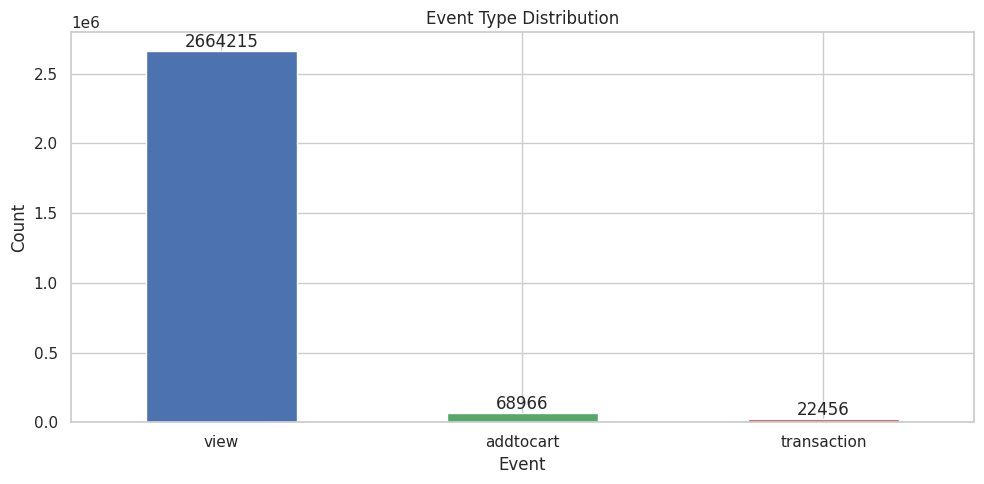

In [240]:
# Event type distribution

plt.figure()
event_counts = train_ui_filtered['event'].value_counts() if 'event' in train_ui_filtered.columns else None

# If the 'event' column is missing, take it from the original events
# (if it is missing in train_ui_filtered, modify the line below)
try:
    event_counts = df['event'].value_counts()   # from the original DF
except:
    event_counts = train_ui_filtered.groupby('event').size() if 'event' in train_ui_filtered.columns else pd.Series()

if not event_counts.empty:
    ax = event_counts.plot(kind='bar', color=['#4c72b0', '#55a868', '#c44e52'])
    plt.title('Event Type Distribution')
    plt.ylabel('Count')
    plt.xlabel('Event')
    plt.xticks(rotation=0)
    for i, v in enumerate(event_counts):
        ax.text(i, v + 0.01*max(event_counts), str(v), ha='center')
    plt.tight_layout()
    plt.show()

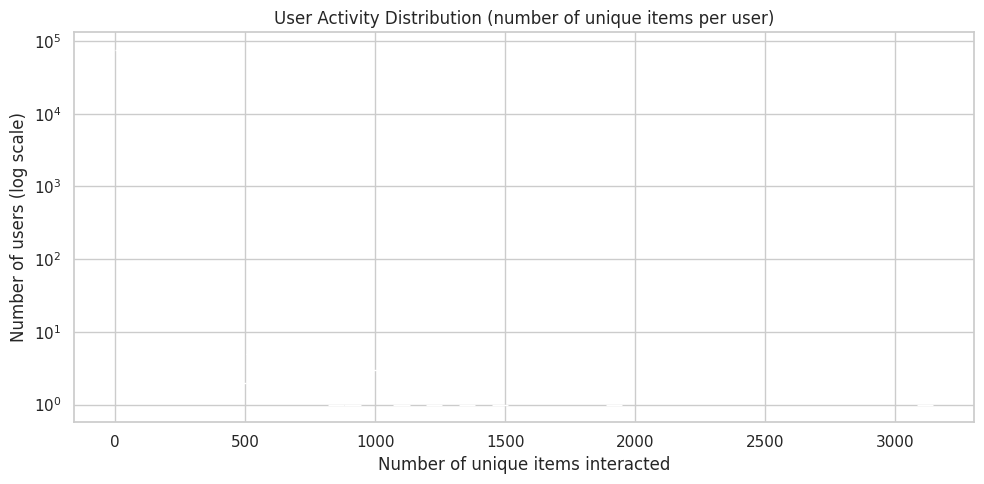

User activity statistics:
count    75276.000000
mean         5.127052
std         24.032391
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max       3145.000000
Name: itemid, dtype: float64


In [241]:
# User activity distribution (number of products viewed)

user_activity = train_ui_filtered.groupby('visitorid')['itemid'].nunique()

plt.figure()
sns.histplot(user_activity, bins=50, log_scale=(False, True), color='#4c72b0')
plt.title('User Activity Distribution (number of unique items per user)')
plt.xlabel('Number of unique items interacted')
plt.ylabel('Number of users (log scale)')
plt.tight_layout()
plt.show()

print("User activity statistics:")
print(user_activity.describe())

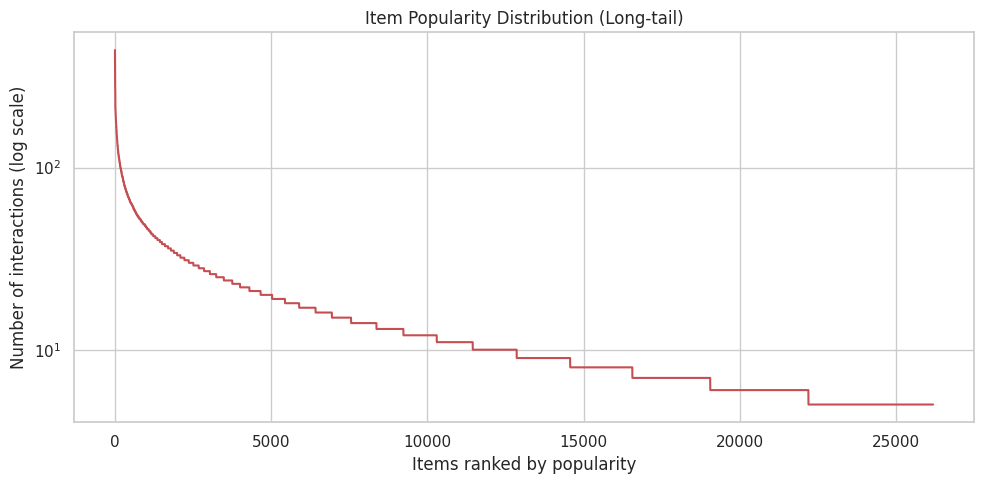

In [242]:
# Item popularity (long-tail)

item_popularity = train_ui_filtered.groupby('itemid').size().sort_values(ascending=False)

plt.figure()
plt.plot(range(len(item_popularity)), item_popularity.values, color='#c44e52')
plt.yscale('log')
plt.title('Item Popularity Distribution (Long-tail)')
plt.xlabel('Items ranked by popularity')
plt.ylabel('Number of interactions (log scale)')
plt.tight_layout()
plt.show()

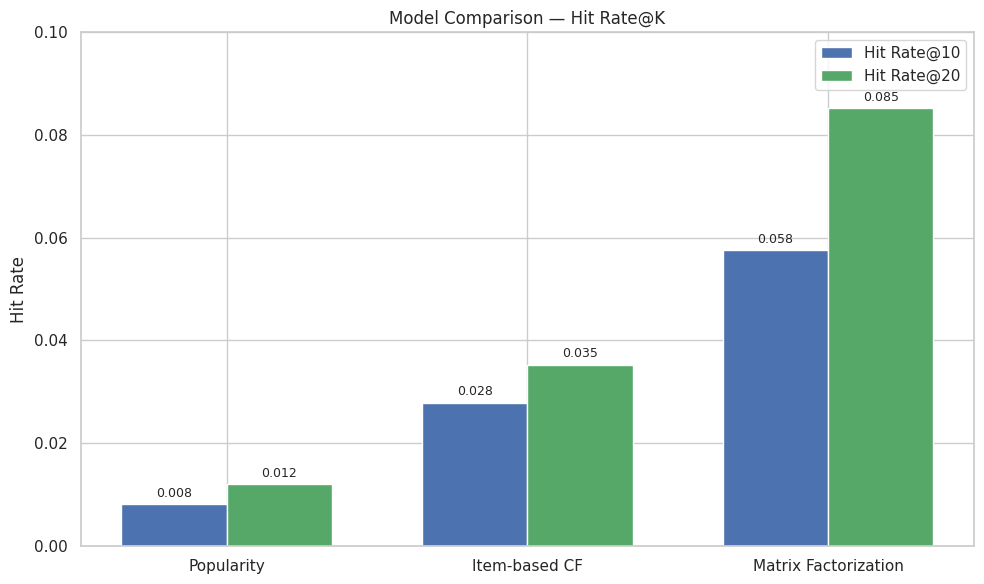

In [243]:
# Model comparison (Hit Rate)

models = ['Popularity', 'Item-based CF', 'Matrix Factorization']
hr10 = [0.0081, 0.0279, 0.0576]
hr20 = [0.0121, 0.0353, 0.0852]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, hr10, width, label='Hit Rate@10', color='#4c72b0')
bars2 = ax.bar(x + width/2, hr20, width, label='Hit Rate@20', color='#55a868')

ax.set_ylabel('Hit Rate')
ax.set_title('Model Comparison — Hit Rate@K')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 0.10)

# Write the values ​​above the bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()